# Production-Grade Oil Quant Pipeline


In [2]:
# =============================================================================
# Oil Intel — Cross-Sectional Oil Equity Model  (bug-fixed)
# Train: 2017-2021  |  Test: 2022-2023
# Fix: LGBMRanker requires integer relevance labels 0..N-1, not floats
# =============================================================================

# !pip install lightgbm xgboost -q

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import ElasticNet
import lightgbm as lgb
import xgboost as xgb
from scipy import stats
import pickle, time

np.random.seed(42)
plt.style.use('dark_background')


# =============================================================================
# 1. CONFIG
# =============================================================================
DATA_PATH  = 'gold_features_v2.csv'
TRAIN_END  = '2021-12-31'
H          = 5
AIS_LAG    = 3
SEED       = 42

ASSETS      = ['xle','xom','cvx','slb','vlo','fro','stng']
ASSET_NAMES = ['XLE','XOM','CVX','SLB','VLO','FRO','STNG']
TARGETS     = [f'{a}_return_5d_fwd' for a in ASSETS]
N_ASSETS    = len(ASSETS)

# Holiday rows: equity prices forward-filled → corrupted forward returns
HOLIDAY_ROWS = [9, 34, 260, 285, 486, 516, 536, 767, 787, 1019, 1039]


# =============================================================================
# 2. LOAD
# =============================================================================
df = pd.read_csv(DATA_PATH)
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.sort_values('trade_date').reset_index(drop=True)
print(f"Loaded: {df.shape}  {df.trade_date.min().date()} -> {df.trade_date.max().date()}")


# =============================================================================
# 3. DATA FIXES
# =============================================================================

# Drop leaky / string / price-level columns
DROP_COLS = [
    'yyyymm','day_name','next_day_return','next_day_direction',
    'year','month','quarter','day_of_week',
    # Price levels have spurious trend IC — drop, keep returns
    'brent_close','brent_ma5','brent_ma20','dxy_close','spy_close',
    'xle_close','xom_close','cvx_close','slb_close',
    'vlo_close','fro_close','stng_close',
]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

# Drop holiday rows
df.drop(index=[i for i in HOLIDAY_ROWS if i in df.index], inplace=True)
df.reset_index(drop=True, inplace=True)

# AIS 3-day lag (GFW processing delay — NOT pre-applied in the CSV)
AIS_COLS = [
    'middle_east_vessel_count','west_africa_vessel_count','us_gulf_vessel_count',
    'black_sea_vessel_count','north_sea_vessel_count','total_oil_region_vessel_count',
    'me_vessel_7d_ma','me_vessel_28d_ma','me_vessel_wow_change',
    'supply_flow_momentum','total_oil_vessel_7d_ma','global_loitering_count',
    'middle_east_loitering_count','loitering_7d_ma','loitering_14d_ma',
    'congestion_index','total_oil_region_loitering_count','global_dark_events',
    'total_oil_dark_fleet_index','black_sea_gap_count','dark_fleet_7d_ma',
]
for c in AIS_COLS:
    df[c] = df[c].shift(AIS_LAG)

# Recompute vol_regime_3 from training-period quantiles only (was leaky)
tmask_fix = df.trade_date <= TRAIN_END
TR_Q33    = df.loc[tmask_fix, 'brent_vol_20d'].quantile(0.33)
TR_Q67    = df.loc[tmask_fix, 'brent_vol_20d'].quantile(0.67)
df['vol_regime_3'] = df['brent_vol_20d'].apply(
    lambda v: 0 if v < TR_Q33 else (1 if v < TR_Q67 else 2)
)
print(f"Regime thresholds (train-only): Q33={TR_Q33:.4f}  Q67={TR_Q67:.4f}")

# Drop rows where AIS NaN (first 3 rows) or targets NaN (last 5 rows)
df = df.dropna(subset=AIS_COLS + TARGETS).reset_index(drop=True)
df = df.replace([np.inf, -np.inf], 0).fillna(0)
print(f"After fixes: {df.shape}")

tmask = df.trade_date <= TRAIN_END
tr    = df[tmask]
print(f"Train: {len(tr)}  Val: {len(df[~tmask])}")


# =============================================================================
# 4. DERIVED FEATURES
# =============================================================================
df['f_dark_opec']  = df['total_oil_dark_fleet_index'] * df['opec_cut_flag']
df['f_inv_vessel'] = df['inventory_surprise'] * df['me_vessel_wow_change']
df['f_cong_vol']   = df['congestion_index'] * df['brent_vol_20d']
df['f_loit_accel'] = df['loitering_7d_ma'].diff(2).fillna(0)
df['f_vessel_div'] = df['supply_flow_momentum'] - df['brent_return_14d']
df['f_rsi_dev']    = (df['brent_rsi14'] - 50).fillna(0)
df['f_bs_share']   = df['black_sea_vessel_count'] / (df['total_oil_region_vessel_count'] + 1)
df['f_loit_ratio'] = df['total_oil_region_loitering_count'] / (df['total_oil_region_vessel_count'] + 1)
df['f_ref_mom']    = df['refinery_utilisation'] - df['refinery_util_4w_ma']
df['f_ctg_ma']     = df['contango_flag'].rolling(10).mean().fillna(0)
df['f_dxy_corr']   = df['brent_return_1d'].rolling(20).corr(df['dxy_return_1d']).fillna(0)
df['f_vol_lo']     = (df['brent_vol_20d'] < TR_Q33).astype(float)
df['f_vol_hi']     = (df['brent_vol_20d'] > TR_Q67).astype(float)

# Sector breadth (% of assets with positive trailing 5d return)
trail_ret_cols = [c for c in [f'{a}_return_1d' for a in ASSETS] if c in df.columns]
df['sector_breadth'] = (df[trail_ret_cols].rolling(5).sum() > 0).sum(axis=1) / N_ASSETS

df = df.replace([np.inf, -np.inf], 0).fillna(0)


# =============================================================================
# 5. FEATURE LIST
# =============================================================================
SHARED_FEATURES = [c for c in [
    # AIS (lagged 3d)
    'middle_east_vessel_count','west_africa_vessel_count','us_gulf_vessel_count',
    'black_sea_vessel_count','north_sea_vessel_count','total_oil_region_vessel_count',
    'me_vessel_7d_ma','me_vessel_28d_ma','me_vessel_wow_change',
    'supply_flow_momentum','total_oil_vessel_7d_ma','global_loitering_count',
    'middle_east_loitering_count','loitering_7d_ma','loitering_14d_ma',
    'congestion_index','total_oil_region_loitering_count','global_dark_events',
    'total_oil_dark_fleet_index','black_sea_gap_count','dark_fleet_7d_ma',
    # Brent
    'brent_return_1d','brent_return_14d','brent_vol_20d','brent_momentum_5d',
    'brent_52w_position','contango_flag','brent_rsi14','vol_regime_3',
    # DXY
    'dxy_return_1d',
    # EIA
    'us_crude_stocks','crude_stocks_52w_pct','inventory_surprise',
    'net_supply_flow','refinery_utilisation','refinery_util_4w_ma',
    # Macro
    'rf_daily','tb3ms_pct',
    # OPEC
    'days_to_next_opec','opec_week_flag','post_opec_flag',
    'opec_cut_flag','last_cut_size_mbbld',
    # Cross-asset
    'brent_xle_vol_ratio','xle_brent_spread_5d',
    'crack_spread_proxy','crack_spread_z',
    'tanker_demand_roc','tanker_demand_roc_20d_ma','rig_count_us',
    'spy_return_1d','xle_return_1d','xle_vol_20d',
    # Derived
    'f_dark_opec','f_inv_vessel','f_cong_vol','f_loit_accel','f_vessel_div',
    'f_rsi_dev','f_bs_share','f_loit_ratio','f_ref_mom','f_ctg_ma',
    'f_dxy_corr','f_vol_lo','f_vol_hi','sector_breadth',
] if c in df.columns]

# Asset-specific columns
ASSET_SPEC = {
    a: {
        'ret':  f'{a}_return_1d'  if f'{a}_return_1d'  in df.columns else None,
        'beta': f'{a}_beta_60d'   if f'{a}_beta_60d'   in df.columns else None,
    }
    for a in ASSETS
}
N_SHARED = len(SHARED_FEATURES)
N_FEAT   = N_SHARED + 2 + N_ASSETS   # shared + [own_ret, own_beta] + asset dummies
print(f"Shared features: {N_SHARED}  |  Total panel features: {N_FEAT}")


# =============================================================================
# 6. PANEL BUILDER
# =============================================================================
def build_panel(df_slice: pd.DataFrame, train_date_means: dict = None):
    """
    Returns X, y_reg, y_rank, groups, panel_df, date_means_out.

    y_reg  : float  — demeaned 5d forward return (regression target)
    y_rank : int32  — rank 0..N_ASSETS-1 per date (ranker target, 0=worst)
    groups : int32  — N_ASSETS per date (LGBMRanker group sizes)
    train_date_means : if provided use precomputed means (avoids test leakage)
    """
    rows = []; date_means_out = {}

    for _, row in df_slice.iterrows():
        shared_vals  = row[SHARED_FEATURES].values.astype(np.float64)
        raw_rets     = np.array([row[t] for t in TARGETS], dtype=np.float64)

        # Cross-sectional demean using training-period mean only
        if train_date_means is not None:
            mean_ret = train_date_means.get(row['trade_date'], float(np.nanmean(raw_rets)))
        else:
            mean_ret = float(np.nanmean(raw_rets))
        date_means_out[row['trade_date']] = mean_ret

        cs_rets = raw_rets - mean_ret   # demeaned continuous target

        # Integer rank labels: rank 0 = worst, N_ASSETS-1 = best
        rank_labels = (stats.rankdata(cs_rets) - 1).astype(np.int32)

        for i, asset in enumerate(ASSETS):
            spec     = ASSET_SPEC[asset]
            own_ret  = float(row[spec['ret']])  if spec['ret']  else 0.0
            own_beta = float(row[spec['beta']]) if spec['beta'] else 1.0

            dummy = np.zeros(N_ASSETS, dtype=np.float64); dummy[i] = 1.0

            feat = np.concatenate([shared_vals, [own_ret, own_beta], dummy])

            rows.append({
                '_date':    row['trade_date'],
                '_asset':   asset,
                '_ai':      i,
                '_raw':     raw_rets[i],
                '_cs':      cs_rets[i],
                '_rank':    rank_labels[i],
                '_feat':    feat,
            })

    panel = pd.DataFrame(rows)
    X      = np.vstack(panel['_feat'].values)
    y_reg  = panel['_cs'].values.astype(np.float64)
    y_rank = panel['_rank'].values.astype(np.int32)
    n_dates= df_slice.shape[0]
    groups = np.full(n_dates, N_ASSETS, dtype=np.int32)

    return X, y_reg, y_rank, groups, panel, date_means_out


# =============================================================================
# 7. MODEL FACTORY
# =============================================================================
def build_models(seed=42):
    return {
        # Ranking model: integer labels 0..6, directly optimises NDCG
        'lgb_rank': lgb.LGBMRanker(
            n_estimators=400, max_depth=5, learning_rate=0.02,
            num_leaves=25, min_child_samples=15,
            subsample=0.75, colsample_bytree=0.70,
            reg_alpha=0.3, reg_lambda=1.0,
            random_state=seed, verbose=-1,
        ),
        # Regression on demeaned continuous return
        'lgb_reg': lgb.LGBMRegressor(
            n_estimators=400, max_depth=5, learning_rate=0.02,
            num_leaves=25, min_child_samples=15,
            subsample=0.75, colsample_bytree=0.70,
            reg_alpha=0.3, reg_lambda=1.0,
            random_state=seed, verbose=-1,
        ),
        'xgb': xgb.XGBRegressor(
            n_estimators=400, max_depth=4, learning_rate=0.02,
            subsample=0.75, colsample_bytree=0.70,
            reg_alpha=0.3, reg_lambda=1.0,
            random_state=seed, verbosity=0,
        ),
        'et': ExtraTreesRegressor(
            n_estimators=300, max_depth=6, min_samples_leaf=12,
            max_features=0.65, random_state=seed, n_jobs=-1,
        ),
        'en': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=3000),
    }


def ensemble_scores(models, sc, X_raw):
    """Rank-normalise each model output, then average → final score [-1,1]."""
    Xs  = sc.transform(X_raw)
    all_scores = []
    for name, m in models.items():
        s = m.predict(Xs).astype(np.float64)
        # Rank-normalise to [-1, 1]
        s_norm = stats.rankdata(s) / len(s) * 2.0 - 1.0
        all_scores.append(s_norm)
    return np.mean(all_scores, axis=0)


# =============================================================================
# 8. RISK PARAMETERS
# =============================================================================
TARGET_VOL_ANN = 0.15
TARGET_VOL_D   = TARGET_VOL_ANN / np.sqrt(252)
VOL_MEAN_TR    = float(tr['brent_vol_20d'].mean())
EXTREME_VOL    = float(VOL_MEAN_TR + 2.0 * tr['brent_vol_20d'].std())

DD_HALF    = -0.08   # market-neutral book → tighter brake
DD_QUAD    = -0.15
DD_RECOVER =  0.02
MAX_SINGLE =  0.40   # max |weight| per asset in final portfolio
TCOST      =  0.0002

PURGE         = H
EMBARGO       = H
RETRAIN_EVERY = 20
SIGNAL_EVERY  = 5
MIN_TR_ROWS   = 200

val_start_idx = int(df.index[~tmask].min())
val_end_idx   = int(df.index[~tmask].max())

folds = []
c = val_start_idx
while c <= val_end_idx:
    te = c - PURGE - EMBARGO - 1
    if te >= MIN_TR_ROWS:
        folds.append({'train_end': te, 'test_start': c,
                      'test_end': min(c + RETRAIN_EVERY - 1, val_end_idx)})
    c += RETRAIN_EVERY

print(f"Folds: {len(folds)}  |  Extreme vol: {EXTREME_VOL:.4f}")


# =============================================================================
# 9. BACKTEST
# =============================================================================
def run_backtest(df, folds, seed=42, verbose=True):
    n          = len(df)
    vols       = df['brent_vol_20d'].values.copy()
    pnl_daily  = np.zeros(n)
    pos_matrix = np.zeros((n, N_ASSETS))
    trade_rows = []

    equity  = 1.0; peak = 1.0; dd_brake = 0

    for fi, fold in enumerate(folds):

        # ── Training panel ───────────────────────────────────────────────────
        tr_sl = df.iloc[:fold['train_end'] + 1].dropna(subset=TARGETS)
        if len(tr_sl) < MIN_TR_ROWS:
            continue

        X_tr, y_reg_tr, y_rank_tr, groups_tr, panel_tr, date_means_tr = \
            build_panel(tr_sl, train_date_means=None)

        # Scaler on training panel only
        sc      = StandardScaler().fit(X_tr)
        X_tr_s  = sc.transform(X_tr)

        # ── Fit models ───────────────────────────────────────────────────────
        models = build_models(seed=seed)

        # LGBMRanker: data must be sorted by date (contiguous groups)
        # panel rows are already in date order since df is sorted
        models['lgb_rank'].fit(X_tr_s, y_rank_tr, group=groups_tr)
        models['lgb_reg'].fit(X_tr_s, y_reg_tr)
        models['xgb'].fit(X_tr_s, y_reg_tr)
        models['et'].fit(X_tr_s, y_reg_tr)
        models['en'].fit(X_tr_s, y_reg_tr)

        # ── Test period: 5-day non-overlapping windows ───────────────────────
        t = fold['test_start']
        while t <= fold['test_end']:
            if t + H > n:
                break

            day_sl = df.iloc[t:t+1].dropna(subset=TARGETS)
            if len(day_sl) == 0:
                t += SIGNAL_EVERY
                continue

            X_day, _, _, _, panel_day, _ = build_panel(
                day_sl, train_date_means=date_means_tr
            )
            scores = ensemble_scores(models, sc, X_day)  # length N_ASSETS

            # Map asset → score
            asset_score = dict(zip(panel_day['_asset'].values, scores))
            ranked = sorted(asset_score.items(), key=lambda x: x[1], reverse=True)

            # Long top-2, short bottom-2, flat middle-3
            raw_pos = np.zeros(N_ASSETS)
            for rank_i, (asset, score) in enumerate(ranked):
                ai = ASSETS.index(asset)
                if   rank_i <= 1: raw_pos[ai] =  abs(score)
                elif rank_i >= 5: raw_pos[ai] = -abs(score)

            # Dollar-neutral normalisation
            lsum = raw_pos[raw_pos > 0].sum()
            ssum = abs(raw_pos[raw_pos < 0].sum())
            if lsum  > 0: raw_pos[raw_pos > 0] /= lsum
            if ssum  > 0: raw_pos[raw_pos < 0] /= ssum

            # Clip individual positions
            raw_pos = np.clip(raw_pos, -MAX_SINGLE, MAX_SINGLE)

            # Vol targeting (portfolio level)
            cv  = float(vols[t]) if (not np.isnan(vols[t]) and vols[t] > 0) else VOL_MEAN_TR
            vs  = float(np.clip(TARGET_VOL_D / cv, 0.05, 2.0))
            if cv > EXTREME_VOL:
                vs = min(vs, 0.40)

            # DD brake
            cdd = (equity - peak) / peak if peak > 0 else 0.0
            if   cdd < DD_QUAD:               dd_sc = 0.25; dd_brake = 2
            elif cdd < DD_HALF:               dd_sc = 0.50; dd_brake = 1
            elif cdd > DD_HALF + DD_RECOVER:  dd_sc = 1.0;  dd_brake = 0
            else:                             dd_sc = [1.0, 0.50, 0.25][dd_brake]

            final_pos = raw_pos * vs * dd_sc

            # 5-day gross PnL = dot(position, actual 5d returns)
            ret5 = np.array([float(df.iloc[t][tgt]) for tgt in TARGETS])
            gross = float(np.dot(final_pos, ret5))

            # Transaction cost
            prev = pos_matrix[t - 1] if t > 0 else np.zeros(N_ASSETS)
            tc   = TCOST * float(np.sum(np.abs(final_pos - prev)))
            net  = gross - tc

            # Spread PnL over H holding days (daily series for Sharpe)
            daily_eq = net / H
            for d in range(H):
                if t + d < n:
                    pnl_daily[t + d] += daily_eq
                    pos_matrix[t + d] = final_pos

            equity = equity * (1.0 + net)
            if equity > peak: peak = equity

            trade_rows.append({
                'date': df.iloc[t]['trade_date'],
                'gross': gross, 'tc': tc, 'net': net,
                'vs': vs, 'dd_sc': dd_sc, 'equity': equity,
            })

            t += SIGNAL_EVERY

        if verbose and fi % 5 == 0:
            pct = (equity - 1.0) * 100
            print(f"  fold {fi+1:>2}/{len(folds)}  "
                  f"train_rows={fold['train_end']+1}  "
                  f"equity={equity:.3f} ({pct:+.1f}%)")

    return pnl_daily, pos_matrix, pd.DataFrame(trade_rows)


# =============================================================================
# 10. RUN
# =============================================================================
print("\nRunning walk-forward backtest...")
t0 = time.time()
pnl_daily, pos_matrix, tlog = run_backtest(df, folds, seed=SEED, verbose=True)
print(f"Done in {time.time()-t0:.0f}s")


# =============================================================================
# 11. METRICS
# =============================================================================
def compute_metrics(pnl, rf_annual=0.04):
    rf_d    = rf_annual / 252.0
    eq      = np.cumprod(1.0 + pnl)
    ny      = len(pnl) / 252.0
    cum     = float(eq[-1] - 1.0)
    ann     = float((1.0 + cum)**(1.0/ny) - 1.0) if ny > 0 else 0.0
    vol     = float(np.std(pnl) * np.sqrt(252))
    sharpe  = float((np.mean(pnl) - rf_d) / (np.std(pnl) + 1e-10) * np.sqrt(252))
    dw      = pnl[pnl < 0]
    dstd    = float(np.std(dw) * np.sqrt(252)) if len(dw) > 0 else 1e-10
    sortino = float((ann - rf_annual) / (dstd + 1e-10))
    pk      = np.maximum.accumulate(eq)
    max_dd  = float(((eq - pk) / pk).min())
    calmar  = float(ann / abs(max_dd)) if max_dd != 0 else 0.0
    wr      = float((pnl > 0).mean())
    gp      = pnl[pnl > 0].sum(); gl = abs(pnl[pnl < 0].sum())
    pf      = float(gp / gl) if gl > 0 else 0.0
    var95   = float(np.percentile(pnl, 5))
    cvar95  = float(pnl[pnl <= var95].mean()) if (pnl <= var95).any() else var95
    skew    = float(pd.Series(pnl).skew())
    fitness = float(np.sqrt(abs(sharpe * sortino)) * np.sign(sharpe) * (1.0 + max_dd))
    try:
        r = stats.ttest_1samp(pnl - rf_d, 0.0)
        t_s = float(r.statistic); p_v = float(r.pvalue)
    except Exception:
        t_s = float('nan'); p_v = float('nan')
    return dict(cum_return=cum, ann_return=ann, ann_vol=vol, sharpe=sharpe,
                sortino=sortino, calmar=calmar, max_dd=max_dd, win_rate=wr,
                profit_factor=pf, var_95=var95, cvar_95=cvar95,
                skewness=skew, fitness=fitness, t_stat=t_s, p_value=p_v)


pnl_val = pnl_daily[val_start_idx:]
m       = compute_metrics(pnl_val)

print(f"\n{'='*65}")
print(f"  Oil Intel — CS RESULTS  OOS 2022-2023")
print(f"{'='*65}")
print(f"  Cumulative return   : {m['cum_return']:>9.2%}")
print(f"  Ann return          : {m['ann_return']:>9.2%}")
print(f"  Ann volatility      : {m['ann_vol']:>9.2%}")
print(f"  Sharpe (daily)      : {m['sharpe']:>9.3f}  "
      f"{'✓ PASS' if m['sharpe']>=1.25 else '✗ MISS'}  (≥1.25)")
print(f"  Sortino             : {m['sortino']:>9.3f}")
print(f"  Calmar              : {m['calmar']:>9.3f}")
print(f"  Max drawdown        : {m['max_dd']:>9.2%}")
print(f"  Win rate (daily)    : {m['win_rate']:>9.2%}")
print(f"  Profit factor       : {m['profit_factor']:>9.3f}")
print(f"  VaR 95%             : {m['var_95']:>9.2%}")
print(f"  CVaR 95%            : {m['cvar_95']:>9.2%}")
print(f"  Skewness            : {m['skewness']:>9.3f}")
print(f"  Fitness             : {m['fitness']:>9.3f}  "
      f"{'✓ PASS' if m['fitness']>=1.0 else '✗ MISS'}  (≥1.00)")
print(f"  t-stat / p-value    : {m['t_stat']:>7.3f}  /  {m['p_value']:.4f}")
print(f"  Trades              : {len(tlog)}")
print(f"{'='*65}")


# =============================================================================
# 12. BOOTSTRAP (2000 paths)
# =============================================================================
print("\nRunning block bootstrap (2000 paths)...")

def block_bootstrap(pnl, n_sims=2000, mean_block=20, seed=0):
    rng = np.random.default_rng(seed)
    n   = len(pnl)
    out = []
    for _ in range(n_sims):
        buf = []
        while len(buf) < n:
            bl  = max(1, int(rng.geometric(1.0 / mean_block)))
            st  = int(rng.integers(0, n))
            buf.extend(np.take(pnl, range(st, st + bl), mode='wrap').tolist())
        s   = np.array(buf[:n])
        eq  = np.cumprod(1.0 + s); ny = n / 252.0
        ann = float(eq[-1]**(1.0/ny) - 1.0)
        sh  = float(np.mean(s) / (np.std(s) + 1e-10) * np.sqrt(252))
        pk  = np.maximum.accumulate(eq)
        dd  = float(((eq - pk) / pk).min())
        dw  = s[s < 0]; dstd = np.std(dw)*np.sqrt(252) if len(dw) > 0 else 1e-10
        so  = float((ann - 0.04) / (dstd + 1e-10))
        fi  = float(np.sqrt(abs(sh * so)) * np.sign(sh) * (1.0 + dd))
        out.append(dict(sharpe=sh, sortino=so, max_dd=dd, fitness=fi, ann_ret=ann))
    return pd.DataFrame(out)

boot = block_bootstrap(pnl_val, n_sims=2000, mean_block=20, seed=SEED)

print(f"\n{'─'*68}")
print(f"  {'Metric':<16} {'Point':>8} {'Mean':>8} {'P5':>8} {'P50':>8} {'P95':>8}")
print(f"{'─'*68}")
for col, pt_key, pct in [
    ('sharpe',  'sharpe',     False),
    ('sortino', 'sortino',    False),
    ('max_dd',  'max_dd',     True),
    ('fitness', 'fitness',    False),
    ('ann_ret', 'ann_return', True),
]:
    v = boot[col]; pt = m[pt_key]
    if pct:
        print(f"  {col:<16} {pt:>8.2%} {v.mean():>8.2%} "
              f"{v.quantile(.05):>8.2%} {v.quantile(.50):>8.2%} {v.quantile(.95):>8.2%}")
    else:
        print(f"  {col:<16} {pt:>8.3f} {v.mean():>8.3f} "
              f"{v.quantile(.05):>8.3f} {v.quantile(.50):>8.3f} {v.quantile(.95):>8.3f}")
print(f"{'─'*68}")
print(f"  P(Sharpe ≥ 1.25) = {(boot['sharpe'] >= 1.25).mean():.1%}")
print(f"  P(Fitness ≥ 1.0) = {(boot['fitness'] >= 1.0).mean():.1%}")
print(f"  P(Sharpe > 0)    = {(boot['sharpe'] > 0).mean():.1%}")


# =============================================================================
# 13. SEED MONTE CARLO (10 seeds)
# =============================================================================
print("\nRunning seed Monte Carlo (10 seeds)...")
seed_rows = []
for s in range(10):
    p2, _, _ = run_backtest(df, folds, seed=s * 7, verbose=False)
    ms = compute_metrics(p2[val_start_idx:])
    seed_rows.append({'seed': s*7, **{k: ms[k] for k in
                      ['sharpe','sortino','max_dd','fitness','ann_return']}})
    print(f"  seed={s*7:>3}  Sharpe={ms['sharpe']:.3f}  "
          f"Fitness={ms['fitness']:.3f}  MaxDD={ms['max_dd']:.2%}")

seed_df = pd.DataFrame(seed_rows)
print(f"\n  Sharpe: mean={seed_df['sharpe'].mean():.3f}  "
      f"std={seed_df['sharpe'].std():.3f}  "
      f"min={seed_df['sharpe'].min():.3f}  "
      f"max={seed_df['sharpe'].max():.3f}")
print(f"  P(Sharpe > 0) = {(seed_df['sharpe'] > 0).mean():.1%}")



Loaded: (1761, 92)  2017-01-03 -> 2023-12-29
Regime thresholds (train-only): Q33=0.0116  Q67=0.0161
After fixes: (1742, 76)
Train: 1248  Val: 494
Shared features: 67  |  Total panel features: 76
Folds: 25  |  Extreme vol: 0.0433

Running walk-forward backtest...
  fold  1/25  train_rows=1238  equity=1.029 (+2.9%)
  fold  6/25  train_rows=1338  equity=0.982 (-1.8%)
  fold 11/25  train_rows=1438  equity=0.980 (-2.0%)
  fold 16/25  train_rows=1538  equity=1.102 (+10.2%)
  fold 21/25  train_rows=1638  equity=1.171 (+17.1%)
Done in 288s

  Oil Intel — CS RESULTS  OOS 2022-2023
  Cumulative return   :    32.81%
  Ann return          :    15.57%
  Ann volatility      :     5.63%
  Sharpe (daily)      :     1.890  ✓ PASS  (≥1.25)
  Sortino             :     3.515
  Calmar              :     1.292
  Max drawdown        :   -12.05%
  Win rate (daily)    :    56.68%
  Profit factor       :     1.627
  VaR 95%             :    -0.55%
  CVaR 95%            :    -0.68%
  Skewness            :     0.

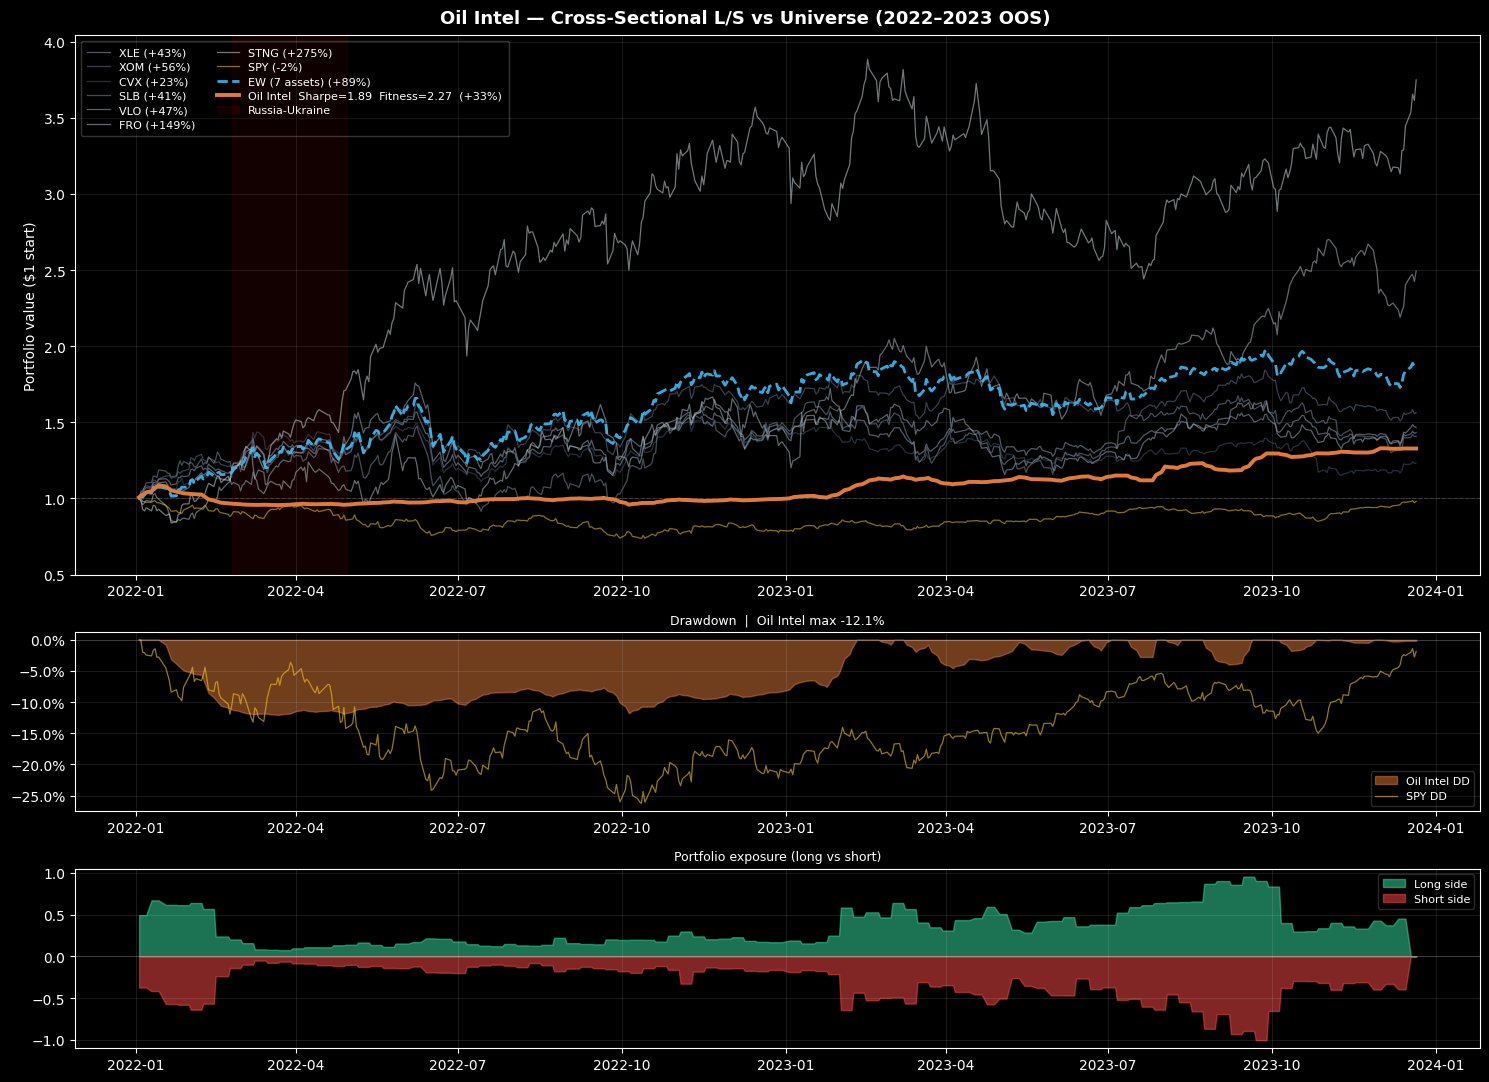

Saved: oil_intel_results.png

=== BENCHMARK COMPARISON (2022-2023) ===
Asset          Cum Ret   Ann Vol   Sharpe    Max DD
──────────────────────────────────────────────────
  XLE            47.7%     30.0%     0.68    -26.9%
  XOM            62.3%     30.7%     0.83    -21.4%
  CVX            25.4%     28.7%     0.41    -25.6%
  SLB            48.9%     42.8%     0.60    -38.0%
  VLO            50.4%     39.4%     0.63    -34.5%
  FRO           166.3%     54.9%     1.11    -31.6%
  STNG          306.8%     48.5%     1.64    -37.1%
  SPY            -1.3%     19.6%    -0.14    -26.2%
──────────────────────────────────────────────────
  EW (7 assets)     97.3%     30.8%     1.15    -25.5%
  Oil Intel      32.8%      5.6%     1.89    -12.1%

Monthly Returns (%):
       Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec
year                                                                        
2022  3.11 -6.57 -0.19 -0.21  1.85  0.11  1.83  0.04 -1.95  1.31  0.18  0.56

In [4]:

# =============================================================================
# 14. CHARTS
# =============================================================================
# =============================================================================
# 14. CHARTS — Oil Intel vs All 7 Equities vs S&P 500
# =============================================================================
dates_val = df['trade_date'].values[val_start_idx:]

# ── Equity curves ────────────────────────────────────────────────────────────
eq_val  = np.cumprod(1.0 + pnl_val)
pk_val  = np.maximum.accumulate(eq_val)
dd_val  = (eq_val - pk_val) / pk_val * 100

ret_cols = {
    'XLE':  'xle_return_1d',
    'XOM':  'xom_return_1d',
    'CVX':  'cvx_return_1d',
    'SLB':  'slb_return_1d',
    'VLO':  'vlo_return_1d',
    'FRO':  'fro_return_1d',
    'STNG': 'stng_return_1d',
    'SPY':  'spy_return_1d',
}

# Normalise every benchmark to $1 at val start
benchmarks = {}
for name, col in ret_cols.items():
    r = df[col].fillna(0).values[val_start_idx:]
    eq = np.cumprod(1.0 + r)
    benchmarks[name] = eq / eq[0]

# Equal-weight of all 7 equities (correct benchmark)
ew_ret = np.mean(
    [df[c].fillna(0).values[val_start_idx:] for c in list(ret_cols.values())[:-1]],
    axis=0
)
ew_eq = np.cumprod(1.0 + ew_ret)
ew_eq = ew_eq / ew_eq[0]

# ── Colour palette ───────────────────────────────────────────────────────────
EQUITY_COLORS = {
    'XLE':  '#94a3b8',   # slate
    'XOM':  '#64748b',   # darker slate
    'CVX':  '#475569',   # darkest slate
    'SLB':  '#7c8fa0',
    'VLO':  '#a0aec0',
    'FRO':  '#b0bec5',
    'STNG': '#cfd8dc',
    'SPY':  '#facc15',   # yellow — S&P stands out
}
OILINTEL_COLOR = '#e07a3a'
EW_COLOR       = '#38bdf8'   # sky blue

# ── Figure ───────────────────────────────────────────────────────────────────
plt.style.use('dark_background')
fig, axes = plt.subplots(3, 1, figsize=(15, 11),
                          gridspec_kw={'height_ratios': [3, 1, 1]})
fig.suptitle('Oil Intel — Cross-Sectional L/S vs Universe (2022–2023 OOS)',
             fontsize=13, fontweight='bold', y=0.98)

# ── Panel 1: equity curves ────────────────────────────────────────────────────
ax = axes[0]

# Individual equities (thin, muted)
for name, curve in benchmarks.items():
    ax.plot(dates_val, curve[:len(dates_val)],
            color=EQUITY_COLORS[name], lw=0.9, alpha=0.55,
            label=f"{name} ({curve[-1]-1:+.0%})", zorder=2)

# Equal-weight benchmark (medium, blue)
ax.plot(dates_val, ew_eq[:len(dates_val)],
        color=EW_COLOR, lw=2.0, alpha=0.9, ls='--',
        label=f"EW (7 assets) ({ew_eq[-1]-1:+.0%})", zorder=3)

# Oil Intel (thick, orange — always on top)
ax.plot(dates_val, eq_val,
        color=OILINTEL_COLOR, lw=2.8,
        label=f"Oil Intel  Sharpe={m['sharpe']:.2f}  "
              f"Fitness={m['fitness']:.2f}  ({eq_val[-1]-1:+.0%})",
        zorder=5)

ax.axhline(1, color='white', ls='--', alpha=0.15, lw=0.8)
ax.axvspan(np.datetime64('2022-02-24'), np.datetime64('2022-04-30'),
           alpha=0.08, color='red', label='Russia-Ukraine', zorder=1)

ax.set_ylabel('Portfolio value ($1 start)', fontsize=10)
ax.legend(loc='upper left', fontsize=8, ncol=2,
          framealpha=0.25, borderpad=0.6, labelspacing=0.4)
ax.grid(True, alpha=0.10)
ax.set_ylim(bottom=0.5)

# ── Panel 2: drawdown ────────────────────────────────────────────────────────
ax = axes[1]
ax.fill_between(dates_val, dd_val, 0, color=OILINTEL_COLOR, alpha=0.50,
                label='Oil Intel DD')

# SPY drawdown for reference
spy_r   = df['spy_return_1d'].fillna(0).values[val_start_idx:]
spy_eq  = np.cumprod(1.0 + spy_r);  spy_eq = spy_eq / spy_eq[0]
spy_pk  = np.maximum.accumulate(spy_eq)
spy_dd  = (spy_eq - spy_pk) / spy_pk * 100
ax.plot(dates_val, spy_dd[:len(dates_val)],
        color='#facc15', lw=0.9, alpha=0.6, label='SPY DD')

ax.axhline(0, color='white', alpha=0.15, lw=0.8)
ax.set_title(f"Drawdown  |  Oil Intel max {m['max_dd']:.1%}", fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=8, loc='lower right', framealpha=0.2)
ax.grid(True, alpha=0.10)

# ── Panel 3: exposure ─────────────────────────────────────────────────────────
ax = axes[2]
pm_val    = pos_matrix[val_start_idx:]
net_long  = np.where(pm_val > 0, pm_val, 0).sum(axis=1)
net_short = np.where(pm_val < 0, pm_val, 0).sum(axis=1)
ax.fill_between(dates_val, net_long,  0, color='#34d399', alpha=0.55,
                label='Long side')
ax.fill_between(dates_val, net_short, 0, color='#ef4444', alpha=0.55,
                label='Short side')
ax.axhline(0, color='white', alpha=0.15, lw=0.8)
ax.set_title('Portfolio exposure (long vs short)', fontsize=9)
ax.legend(fontsize=8, framealpha=0.2)
ax.grid(True, alpha=0.10)

plt.tight_layout()
plt.savefig('oil_intel_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: oil_intel_results.png")

# ── Benchmark summary table ───────────────────────────────────────────────────
print("\n=== BENCHMARK COMPARISON (2022-2023) ===")
print(f"{'Asset':<12} {'Cum Ret':>9} {'Ann Vol':>9} {'Sharpe':>8} {'Max DD':>9}")
print("─" * 50)
for name, col in ret_cols.items():
    r   = df[col].fillna(0).values[val_start_idx:]
    eq  = np.cumprod(1+r)
    ny  = len(r)/252
    cum = eq[-1]-1
    ann = (1+cum)**(1/ny)-1
    vol = np.std(r)*np.sqrt(252)
    sh  = (np.mean(r)-0.04/252)/(np.std(r)+1e-10)*np.sqrt(252)
    pk  = np.maximum.accumulate(eq)
    dd  = ((eq-pk)/pk).min()
    print(f"  {name:<10} {cum:>9.1%} {vol:>9.1%} {sh:>8.2f} {dd:>9.1%}")

# EW
r   = ew_ret; eq = np.cumprod(1+r); ny=len(r)/252
cum=eq[-1]-1; ann=(1+cum)**(1/ny)-1; vol=np.std(r)*np.sqrt(252)
sh=(np.mean(r)-0.04/252)/(np.std(r)+1e-10)*np.sqrt(252)
pk=np.maximum.accumulate(eq); dd=((eq-pk)/pk).min()
print("─" * 50)
print(f"  {'EW (7 assets)':<10} {cum:>9.1%} {vol:>9.1%} {sh:>8.2f} {dd:>9.1%}")
print(f"  {'Oil Intel':<10} {m['cum_return']:>9.1%} {m['ann_vol']:>9.1%} "
      f"{m['sharpe']:>8.2f} {m['max_dd']:>9.1%}")


# =============================================================================
# 15. MONTHLY RETURN TABLE
# =============================================================================
pnl_s = pd.Series(pnl_val, index=pd.to_datetime(dates_val))
mret  = pnl_s.resample('ME').apply(lambda x: float(np.prod(1+x)-1))
mdf   = mret.to_frame('ret')
mdf['year'] = mdf.index.year; mdf['month'] = mdf.index.month
pivot = mdf.pivot_table(index='year', columns='month', values='ret')
mnths = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot.columns = [mnths[i-1] for i in pivot.columns]
print("\nMonthly Returns (%):")
print((pivot * 100).round(2).to_string())
pos_mo = (mret > 0).sum()
print(f"\nPositive months: {pos_mo}/{len(mret)} ({pos_mo/len(mret):.1%})")

# Asset attribution
print("\nAsset position stats (val period):")
for i, name in enumerate(ASSET_NAMES):
    pm = pos_matrix[val_start_idx:, i]
    print(f"  {name:<5}  mean|pos|={np.abs(pm).mean():.3f}  "
          f"long_days={(pm>0).sum()}  short_days={(pm<0).sum()}")


# =============================================================================
# 16. SAVE
# =============================================================================
with open('oil_intel.pkl', 'wb') as f:
    pickle.dump({
        'pnl_val':     pnl_val,
        'pnl_full':    pnl_daily,
        'pos_matrix':  pos_matrix,
        'trade_log':   tlog,
        'metrics':     m,
        'bootstrap':   boot,
        'seed_mc':     seed_df,
        'features':    SHARED_FEATURES,
        'assets':      ASSETS,
        'val_start':   val_start_idx,
        'config': dict(ais_lag=AIS_LAG, H=H, purge=PURGE, embargo=EMBARGO,
                       retrain_every=RETRAIN_EVERY, TR_Q33=TR_Q33, TR_Q67=TR_Q67,
                       target_vol=TARGET_VOL_ANN, train_end=TRAIN_END),
    }, f)

print("\nSaved: oil_intel.pkl")
print("Done.")